# 3D Symmetric Stage Design

A symmetric stage is a turbine or compressor configuration where the inlet and outlet geometry are identical, making it suitable for bidirectional flow applications such as shock tubes and certain reversible turbomachinery designs. Because the stage geometry is mirrored, flow can enter from either end and produce equivalent performance.

A turbine or compressor stage consists of stator-rotor pairs or rotor-rotor pairs. You can chain together multiple stages to design the entire turbine using this code, and control the spacing between blade rows.

**This tutorial covers the following steps:**

1. Stator blade design (2D airfoil profiles assembled into a 3D blade)
2. Rotor blade design (2D airfoil profiles assembled into a 3D blade)
3. 3D blade construction with sweep, lean, and stacking
4. Passage assembly with hub and shroud endwalls
5. Export to JSON and DAT formats

**Technical definitions used throughout:**
- Airfoils are 2D cross-sectional profiles
- Blades are 3D bodies made up of multiple airfoil profiles stacked spanwise
- A Stage is made up of a stator blade row and a rotor blade row
- A full turbine design is made up of multiple stages

In [1]:
# Installation
!pip install pyturbo-aero

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 12.0 MB/s eta 0:00:00


In [2]:
# Import scripts
from typing import List
import numpy as np
from pyturbo.aero import Airfoil2D, Airfoil3D, Passage2D
from pyturbo.helper import exp_ratio, bezier, pw_bezier2D,StackType

## Creating a Stator Blade

Stator blades are non-rotating components that redirect the flow without doing work on the fluid. Their purpose is to guide the flow into the rotor at the correct angle to maximize power extraction and efficiency. Because stators do not rotate, they are designed with zero rotational velocity and typically feature higher turning angles than rotor blades.

The design is governed by the velocity triangles obtained from a 1D meanline or streamline throughflow analysis.

Below is an example of creating a stator blade using hub, mid, and tip profiles. You can have as many spanwise profiles as you want -- just specify their radial locations when instantiating the 3D airfoil. Later, the flip operation reorients the blade so that its axial direction aligns with the passage coordinate system.

### Hub Profile

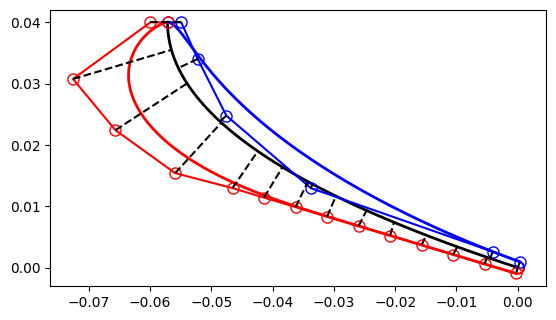

In [3]:
stator_hub_axial_chord = 0.040
#This creates the camberline
stator_hub = Airfoil2D(alpha1=0,alpha2=72,axial_chord=stator_hub_axial_chord,stagger=55)
stator_hub.add_le_thickness(0.04)

ps_height = [0.0500,0.0200,-0.0100] # These are thicknesses
stator_hub.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.2400, 0.2000, 0.1600, 0.1400]
stator_hub.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

stator_hub.match_thickness(location='LE')
stator_hub.te_create(radius=0.001,wedge_ss=2.5,wedge_ps=2.4)
stator_hub.add_ss_flow_guidance_2(s_c=0.75,n=10)
stator_hub.plot2D()

### Mid Profile

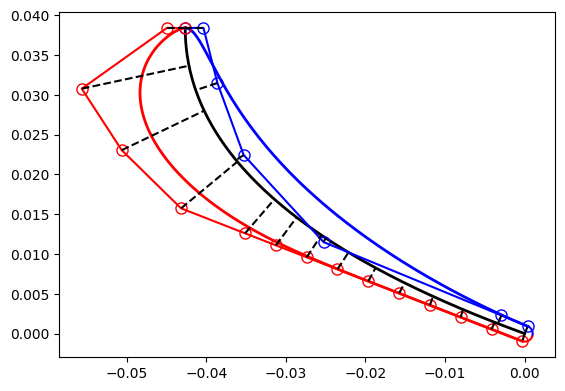

In [4]:

stator_mid = Airfoil2D(alpha1=0,alpha2=70,axial_chord=stator_hub_axial_chord*0.96,stagger=48)
stator_mid.add_le_thickness(0.04)

ps_height = [0.0500,0.0200,-0.0100] # These are thicknesses
stator_mid.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.2400, 0.2000, 0.1600, 0.1400]
stator_mid.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

stator_mid.match_thickness(location='LE')
stator_mid.te_create(radius=0.001,wedge_ss=2.5,wedge_ps=2.4)
stator_mid.add_ss_flow_guidance_2(s_c=0.75,n=10)
stator_mid.plot2D()

### Tip Profile

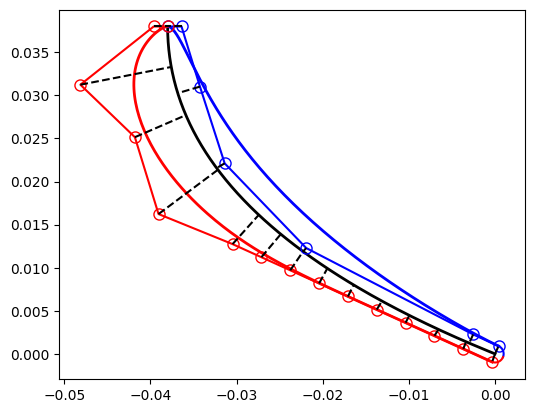

In [5]:
stator_tip = Airfoil2D(alpha1=0,alpha2=68,axial_chord=stator_hub_axial_chord*0.95,stagger=45)
stator_tip.add_le_thickness(0.03)

ps_height = [0.0500,0.0200,0.0100] # These are thicknesses
stator_tip.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.200, 0.1200, 0.1600, 0.1400]
stator_tip.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

stator_tip.match_thickness(location='LE')
stator_tip.te_create(radius=0.001,wedge_ss=2.5,wedge_ps=2.4)
stator_tip.add_ss_flow_guidance_2(s_c=0.75,n=10)
stator_tip.plot2D()

### 3D Stator Blade
Notice that profileArray contains all the hub, mid, tip profiles. The location of these profiles are passed as percentages in profile_loc.

The height doesn't really matter because when we construct the passage curves for hub and shroud, the height will automatically be scaled.

Stacking of the stator is done using the leading edge point. This can be changed to centroid or trailing_edge.

In [6]:
stator3D = Airfoil3D(profileArray=[stator_hub,stator_mid,stator_tip], profile_loc=[0.0,0.5,1.0], height = 0.04)
stator3D.stack(StackType.Leading_Edge) # stators are typically stacked with leading edge; stators with centroid or trailing edge
stator3D.add_sweep(sweep_y=[0,-0.05,0.01], sweep_z=[0.0, 0.5, 1]) # Z =1 is blade tip, Z = 0 is blade hub. The units are in percentage
stator3D.add_lean(leanX=[0,0.1,0.05], leanZ=[0,0.5,1])
stator3D.build(nProfiles=20,num_points=160,trailing_edge_points=20)

/usr/local/lib/python3.12/dist-packages/pyturbo/helper/bezier.py:380: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  temp = minimize_scalar(f2,bounds=(t_start,t_end),method="bounded",tol=1e-6,args=(t_start))
Equal Spacing suction and pressure side: 100%|██████████| 20/20 [00:00<00:00, 114.86it/s]


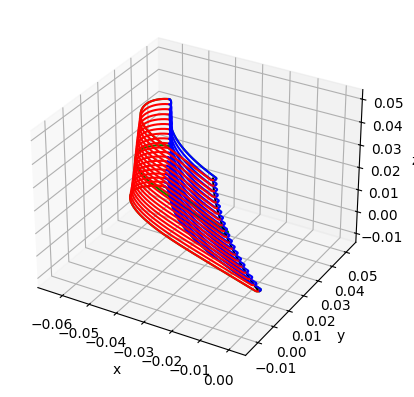

In [ ]:
stator3D.plot3D()

## Creating a Rotor Blade

Rotor blades are the rotating components that extract energy from (turbine) or add energy to (compressor) the working fluid. In a symmetric stage, the rotor is designed to be bidirectional so that it performs equivalently regardless of flow direction.

Notice the difference in metal turning angle and stagger angle compared to the stator 2D airfoils. The rotor inlet metal angle (alpha1) is non-zero because the flow has already been turned by the upstream stator. The suction-side wedge angle is also adjusted to accommodate the different loading distribution on a rotating blade.

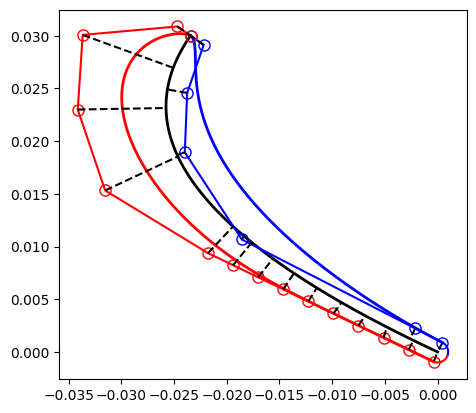

In [7]:
rotor_axial_chord = 0.030
rotor_hub = Airfoil2D(alpha1=35,alpha2=65,axial_chord=rotor_axial_chord,stagger=38)
rotor_hub.add_le_thickness(0.04)

ps_height = [0.0500,0.0200,-0.0100] # These are thicknesses
rotor_hub.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.2400, 0.2200, 0.2000, 0.1800]
rotor_hub.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

rotor_hub.match_thickness(location='LE')
rotor_hub.te_create(radius=0.001,wedge_ss=3.5,wedge_ps=2.4)
rotor_hub.add_ss_flow_guidance_2(s_c=0.75,n=10)
rotor_hub.plot2D()

### Mid Profile

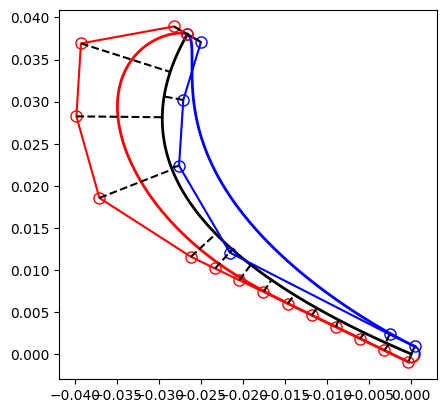

In [10]:
rotor_mid = Airfoil2D(alpha1=30,alpha2=67,axial_chord=0.038,stagger=35)
rotor_mid.add_le_thickness(0.04)

ps_height = [0.0500,0.0200,-0.0100] # These are thicknesses
rotor_mid.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.2400, 0.2200, 0.2000, 0.1800]
rotor_mid.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

rotor_mid.match_thickness(location='LE')
rotor_mid.te_create(radius=0.001,wedge_ss=3.5,wedge_ps=2.4)
rotor_mid.add_ss_flow_guidance_2(s_c=0.75,n=10)
rotor_mid.plot2D()

### Tip Profile

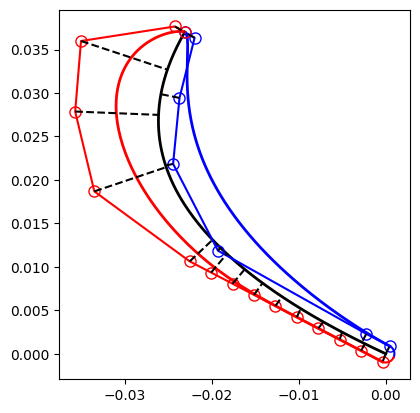

In [11]:
rotor_tip = Airfoil2D(alpha1=30,alpha2=65,axial_chord=0.037,stagger=32)
rotor_tip.add_le_thickness(0.03)

ps_height = [0.0500,0.0200,-0.0100] # These are thicknesses
rotor_tip.add_ps_thickness(thicknessArray=ps_height,expansion_ratio=1.2)

ss_height=[0.2400, 0.2200, 0.2000, 0.1800]
rotor_tip.add_ss_thickness(thicknessArray=ss_height,camberPercent=0.8,expansion_ratio=1.2)

rotor_tip.match_thickness(location='LE')
rotor_tip.te_create(radius=0.001,wedge_ss=3.5,wedge_ps=2.4)
rotor_tip.add_ss_flow_guidance_2(s_c=0.7,n=10)
rotor_tip.plot2D()

### 3D Rotor Blade
This is defined similarly to the stator blade. The only difference is the centroid stacking.

In [12]:
rotor3D = Airfoil3D(profileArray=[rotor_hub,rotor_mid,rotor_tip],profile_loc=[0.0,0.5,1.0], height = 0.04)
rotor3D.stack(StackType.Trailing_Edge) # stators are typically stacked with leading edge; stators with centroid or trailing edge
# rotor3D.add_sweep(sweep_y=[0,-0.02,0.02], sweep_z=[0.0, 0.5, 1]) # Z =1 is blade tip, Z = 0 is blade hub. The units are in percentage
# rotor3D.add_lean(leanX=[0,0.01,-0.02],leanZ=[0,0.5,1])
rotor3D.build(nProfiles=20,num_points=60,trailing_edge_points=20)
# rotor3D.plot3D()

Equal Spacing suction and pressure side: 100%|██████████| 20/20 [00:00<00:00, 277.77it/s]


## Matching the beginning slope
The code below modifies the bezier curve to add an extra control point after the starting point to match the first derivative at the end of the previous bezier curve. Having something like this is useful for creating a smooth continous curve. Tweaks can be made to the second point to match the 2nd derivative if needed.



In [13]:
def match_end_slope(bezier1:bezier, x:List[float],y:List[float]):
    """Creates another bezier curve that matches the slope at the end of bezier 1

    Args:
        bezier1 (bezier):
        x (List[float]): Bezier control points
        y (List[float]): Bezier control points

    Returns:
        bezier: new bezier curve containing control points x,y with extra points interjected at the 2nd index x[1],y[1] to match the end slope of bezier1
    """
    # Look at the last 2 points of the previous bezier curve. These 2 points control the slope
    x1 = bezier1.x[-2:]
    y1 = bezier1.y[-2:]

    dx = np.diff(x1)[0]    # Find the spacing
    dy = np.diff(y1)[0]
    x2 = x[0]+dx
    y2 = y[0]+dy

    d1 =2; d2=1 # Set these values so loop is executed.
    while d1>d2:    # Loop exists so that new points fall in between existing points
        # Add extra control point (x2,y2) into list, need to adjust control point
        dx = x[0]-x2
        dy = y[0]-y2
        d1 = np.sqrt((dx)**2 + (dy)**2)
        d2 = np.sqrt((x[0]-x[1])**2 + (y[0]-y[1])**2)

        if d1>d2:
            x2 += dx*0.2 # Reduce both by 80%, this keeps the slope the same
            y2 += dy*0.2

    x.insert(1,x2)
    y.insert(1,y2)

    b = bezier(x,y)
    return b


## Endwalls
The code below demonstrates how to create the Hub and Shroud curves.
To change the shroud height, just change the rtip. Modifying the hub_tip_ratio increases the passage area.

In [14]:
# Endwalls Parameters
rtip = 0.25 # meters
hub_tip_ratio = 0.8
rhub = rtip*hub_tip_ratio
stator_rotor_gap = 0.025

### Hub
The hub profiles are separated into
1. Inlet to Stator leading edge
2. Stator Leading edge to Mid Stator-Rotor gap
3. Mid Stator-Rotor gap to Rotor TE + 0.5*Stator-Rotor gap

In [15]:

rhub_expansion_coeff1 = [1.0,0.98,0.97] # Stator
zhub_expansion_coeff1 = [0.25,0.75]

# This makes the flowpath going from inlet to stator leading edge
rhub_points1 = [rhub, rhub]  # 1.5x Stator Inlet, stator_inlet, stator_mid
zhub_points1 = [-1.5*stator_hub_axial_chord,0]
hub_bezier1 = bezier(zhub_points1,rhub_points1)

# Flowpath from stator leading edge to trailing edge
rhub_points2 = [rhub]
zhub_points2 = [0]
rhub_points2.append(rhub*rhub_expansion_coeff1[0])                      # Mid bezier control point
zhub_points2.append(stator_hub_axial_chord*zhub_expansion_coeff1[0]) # type: ignore

rhub_points2.append(rhub*rhub_expansion_coeff1[1])                      # End bezier control point
zhub_points2.append(stator_hub_axial_chord*zhub_expansion_coeff1[1]) # type: ignore

rhub_points2.append(rhub*rhub_expansion_coeff1[2])                      # End bezier point
zhub_points2.append(stator_hub_axial_chord+stator_rotor_gap*0.5) # type: ignore

rhub_points2 = np.array(rhub_points2)
zhub_points2 = np.array(zhub_points2)

hub_bezier2 = match_end_slope(hub_bezier1,zhub_points2.tolist(),rhub_points2.tolist())

# Mid stator-rotor gap to rotor_te + stator-rotor gap
rhub_expansion_coeff2 = [0.99,0.98,1.0,1.0] # Rotor
zhub_expansion_coeff2 = [0.5,0.80]
rhub_points3 = [rhub_points2[-1]]
zhub_points3 = [zhub_points2[-1]] # This will be adjusted at the end

rhub_points3.append(rhub_points2[-1]*rhub_expansion_coeff2[0]) # Rotor Inlet
zhub_points3.append(zhub_points2[-1]+stator_rotor_gap*0.5)

rhub_points3.append(rhub_points2[-1]*rhub_expansion_coeff2[1]) # Rotor Mid
zhub_points3.append(zhub_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord*zhub_expansion_coeff2[0])

rhub_points3.append(rhub_points2[-1]*rhub_expansion_coeff2[2]) # Rotor TE
zhub_points3.append(zhub_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord*zhub_expansion_coeff2[1])

rhub_points3.append(rhub_points2[-1]*rhub_expansion_coeff2[3]) # Rotor TE + stator_rotor_gap
zhub_points3.append(zhub_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord+stator_rotor_gap*0.5)

rhub_points3 = np.array(rhub_points3)
zhub_points3 = np.array(zhub_points3)

hub_bezier3 = match_end_slope(hub_bezier2,zhub_points3.tolist(),rhub_points3.tolist())

rhub_points4 = [rhub_points3[-1], rhub_points3[-1]]
zhub_points4 = [zhub_points3[-1], zhub_points3[-1]+2.5*rotor_axial_chord]
hub_bezier4 = match_end_slope(hub_bezier3,zhub_points4,rhub_points4)


### Shroud
Shroud profiles are defined similarly to the hub profiles


In [16]:
rshroud_expansion_coeff1 = [1.04,1.05,1.06] # Stator
zshroud_expansion_coeff1 = [0.25,0.9]

# This makes the flowpath going from inlet to stator leading edge
rshroud_points1 = [rtip, rtip]  # 1.5x Stator Inlet, stator_inlet, stator_mid
zshroud_points1 = [-1.5*stator_hub_axial_chord,0]
shroud_bezier1 = bezier(zshroud_points1,rshroud_points1)

# Flowpath from stator leading edge to trailing edge
rshroud_points2 = [rtip]
zshroud_points2 = [0]
rshroud_points2.append(rtip*rshroud_expansion_coeff1[0])                      # Mid bezier control point
zshroud_points2.append(stator_hub_axial_chord*0.5) # type: ignore

rshroud_points2.append(rtip*rshroud_expansion_coeff1[1])                      # End bezier control point
zshroud_points2.append(stator_hub_axial_chord*0.5+stator_hub_axial_chord*0.5*zshroud_expansion_coeff1[0]) # type: ignore

rshroud_points2.append(rtip*rshroud_expansion_coeff1[2])                      # End bezier point
zshroud_points2.append(stator_hub_axial_chord+stator_rotor_gap*0.5) # type: ignore

rshroud_points2 = np.array(rshroud_points2)
zshroud_points2 = np.array(zshroud_points2)

shroud_bezier2 = match_end_slope(shroud_bezier1,zshroud_points2.tolist(),rshroud_points2.tolist())

# Mid stator-rotor gap to rotor_te + stator-rotor gap
rshroud_expansion_coeff2 = [1.0,1.0,1.0,1.0] # Rotor
zshroud_expansion_coeff2 = [0.40,0.8]
rshroud_points3 = [rshroud_points2[-1]]
zshroud_points3 = [zshroud_points2[-1]] # This will be adjusted at the end

rshroud_points3.append(rshroud_points2[-1]*rshroud_expansion_coeff2[0]) # Rotor Inlet
zshroud_points3.append(zshroud_points2[-1]+stator_rotor_gap*0.5)

rshroud_points3.append(rshroud_points2[-1]*rshroud_expansion_coeff2[1]) # Rotor Mid
zshroud_points3.append(zshroud_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord*zshroud_expansion_coeff2[0])

rshroud_points3.append(rshroud_points2[-1]*rshroud_expansion_coeff2[2]) # Rotor TE
zshroud_points3.append(zshroud_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord*zshroud_expansion_coeff2[1])

rshroud_points3.append(rshroud_points2[-1]*rshroud_expansion_coeff2[3]) # Rotor TE + stator_rotor_gap
zshroud_points3.append(zshroud_points2[-1]+stator_rotor_gap*0.5+rotor_axial_chord+stator_rotor_gap*0.5)

rshroud_points3 = np.array(rshroud_points3)
zshroud_points3 = np.array(zshroud_points3)

shroud_bezier3 = match_end_slope(shroud_bezier2,zshroud_points3.tolist(),rshroud_points3.tolist())

rshroud_points4 = [rshroud_points3[-1], rshroud_points3[-1]]
zshroud_points4 = [zshroud_points3[-1], zshroud_points3[-1]+2.5*rotor_axial_chord]
shroud_bezier4 = match_end_slope(shroud_bezier3,zshroud_points4,rshroud_points4)


The code below joins the bezier curves kind of like a piecewise curve. I wrote it to simplify my life. It also plots all the curves.

In [17]:
hub_bezier = pw_bezier2D([hub_bezier1,hub_bezier2,hub_bezier3,hub_bezier4])
shroud_bezier = pw_bezier2D([shroud_bezier1,shroud_bezier2,shroud_bezier3,shroud_bezier4])

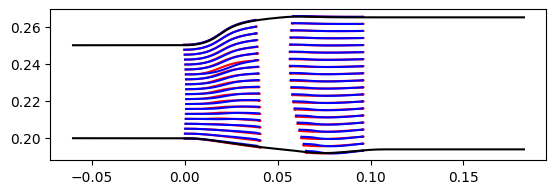

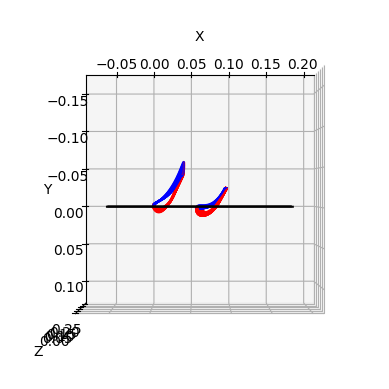

In [ ]:
# Passage plotting is done after passage creation below


## Creating the Passage in 2D

The passage is the flow path between the hub and shroud endwalls. It contains both the stator and rotor blade rows, separated by a gap that allows for mixing and transition between the stationary and rotating frames of reference.

Before adding the blades to the passage, the geometry orientation must be adjusted. The 2D airfoil design convention places the axial (leading-edge to trailing-edge) direction along the Y axis and the tangential (R-theta) direction along the X axis. The flip and rotate operations below reorient the blades so that the axial direction aligns with the passage coordinate system.

In [18]:

import copy
stator_adjusted = copy.deepcopy(stator3D)
rotor_adjusted = copy.deepcopy(rotor3D)

stator_adjusted.center_le()
stator_adjusted.flip_x()
stator_adjusted.rotate(cx=0,cy=0,angle=90)
# stator_adjusted.plot3D()

rotor_adjusted.center_le()
rotor_adjusted.flip_x()
rotor_adjusted.rotate(cx=0,cy=0,angle=90)

# rotor_adjusted.rotate(cx=0,cy=0,angle=90)


Now that the geometry is orientated propperly, we can add it to a 2D Passage.

In [19]:
passage = Passage2D([stator_adjusted,rotor_adjusted],[stator_rotor_gap])

zhub,rhub = hub_bezier.get_point(np.linspace(0,1,100))
zshroud,rshroud = shroud_bezier.get_point(np.linspace(0,1,100))
passage.add_endwalls(zhub,rhub,zshroud,rshroud)
passage.blade_fit(0)



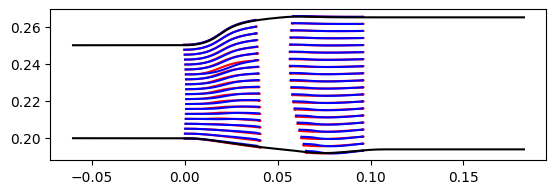

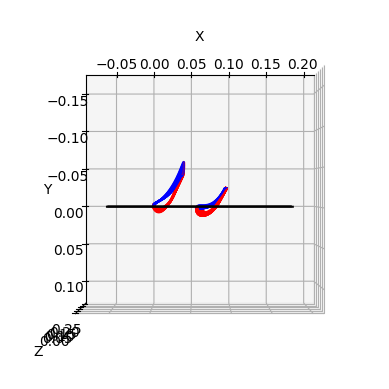

In [ ]:
passage.plot2D()
passage.plot3D()

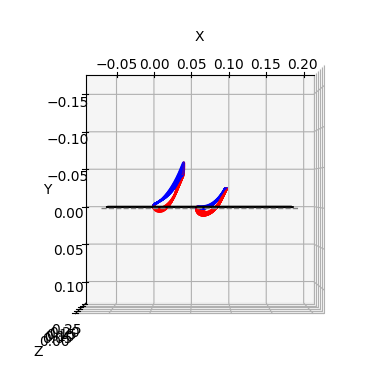

In [20]:
fig = passage.plot3D()

The passage data can now be exported to a json or a dat file. If you are using a CFD Program like Numeca or ADS, I encourage you to look at the code for export_dat or json and create your own code to export to the CFD's specific format. Please share the code with others and/or contact me and we can work on including your code in the codebase.

In [21]:
passage.export_json()
passage.export_dat()

In [ ]:
!cat aero_geometry.dat

NBlades 2
Blade 0
	npoints 180
	nsections 20
	section 0
		xss rth_ss r xps rth_ps r
		0.000000 0.000000 0.199800 0.000000 0.000000 0.199800
		0.000006 0.000072 0.199800 0.000000 -0.000002 0.199800
		0.000019 0.000189 0.199800 0.000003 -0.000058 0.199800
		0.000039 0.000333 0.199800 0.000008 -0.000107 0.199800
		0.000063 0.000471 0.199800 0.000014 -0.000156 0.199800
		0.000079 0.000560 0.199800 0.000022 -0.000214 0.199800
		0.000097 0.000637 0.199800 0.000036 -0.000288 0.199800
		0.000121 0.000728 0.199800 0.000051 -0.000361 0.199800
		0.000172 0.000895 0.199800 0.000060 -0.000403 0.199800
		0.000252 0.001137 0.199800 0.000069 -0.000441 0.199800
		0.000321 0.001327 0.199800 0.000076 -0.000471 0.199800
		0.000425 0.001588 0.199800 0.000085 -0.000500 0.199800
		0.000526 0.001822 0.199800 0.000096 -0.000532 0.199800
		0.000654 0.002099 0.199800 0.000107 -0.000563 0.199800
		0.000787 0.002366 0.199800 0.000124 -0.000604 0.199800
		0.000934 0.002643 0.199799 0.000145 -0.000653 0.199800
		0.0

## Cross-Sectional Area and Blade Volume

The cross-sectional area at a given spanwise index and the total blade volume are useful for structural analysis, weight estimation, and manufacturing planning. The hub (index 0) and tip (last index) areas bound the range of cross-sections along the span.

In [22]:
# Compute cross-sectional areas and volume for stator and rotor
for name, blade in [("Stator", stator3D), ("Rotor", rotor3D)]:
    area_hub = blade.get_cross_sectional_area(0)
    area_tip = blade.get_cross_sectional_area(blade.shft_ss.shape[0] - 1)
    volume = blade.get_blade_volume()
    print(f"{name}: Area hub={area_hub:.6f}, Area tip={area_tip:.6f}, Volume={volume:.8f}")

Stator: Area hub=0.000567, Area tip=0.000323, Volume=0.00001669
Rotor: Area hub=0.000207, Area tip=0.000270, Volume=0.00001129
